<a href="https://colab.research.google.com/github/JustinStutler/sarkar-computer-vision-lectures/blob/main/CV_3_1_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision | Module 3_1 HW
### Justin Stutler

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Correlation Assignment

In [2]:
import numpy as np
h = np.array([[-1, 1],[-1, 1]])
f = np.zeros((10,10))
f[3:8,3:8] = np.ones((5, 5)) #block assignment of values

# STEP 1 : Correlate the inverted image with h using zero padding
# INIT z = 1-f
# invert image
z = 1 - f

print("Image f=\n", f, "\nFilter/Kernel h=\n", h)
print("z = 1-f\n", z) # PRINT z
#--------------------------------------------------------
# Zero-Padding Rule
def my_array_ref (a, i, j):
    if ((i >= 0) & (i < a.shape [0]) & (j >= 0) & (j < a.shape [1])):
        return a[i, j] # return in-bound pixel
    return 0 # else return 0
#--------------------------------------------------------
# using kernal indicies
g = np.zeros((10, 10)) #output array
for i in range(f.shape[0]) :
    for j in range (f.shape[1]):
        prod_sum = 0.0
        for k in range (h.shape[0]) :
            for l in range (h.shape[1]) :
                prod_sum = prod_sum + my_array_ref(h, k, l) * my_array_ref(z, i+k, j+l) # changed f --> z = 1-f
        g[i, j] = prod_sum

print("Zero Padding Pass 1\n", g)

#--------------------------------------------------------
# useing image indicies
g = np.zeros((10, 10)) #output array
for i in range(f.shape[0]) :
    for j in range (f.shape[1]):
        prod_sum = 0.0
        for r in range (i, i + h.shape[0]) :
            for s in range (j, j + h.shape[1]) :
                prod_sum = prod_sum + my_array_ref(h, r-i, s-j) * my_array_ref(z, r, s) # f --> z
        g[i, j] = prod_sum

print("Zero Padding Pass 2\n", g)

z_zero = g.copy() # save calculation
print("Zero padding: z correlated with h\n", z_zero)

# STEP 2: return nearest boundary value
def my_array_ref(a, i, j):
  i = min(max(i, 0), a.shape[0] - 1)
  j = min(max(j, 0), a.shape[1] - 1)
  return a[i, j]

# STEP 3: Recompute correlation using nearest boundary
g = np.zeros((10, 10)) #output array
for i in range(f.shape[0]) :
    for j in range (f.shape[1]):
        prod_sum = 0.0
        for r in range (i, i + h.shape[0]) :
            for s in range (j, j + h.shape[1]) :
                prod_sum = prod_sum + my_array_ref(h, r-i, s-j) * my_array_ref(z, r, s) # f-->z
        g[i, j] = prod_sum

z_boundary = g.copy() # save calculation
print("Boundary replication: z correlated with h\n", z_boundary)

# STEP 4: Compare STEP 1 and STEP 3
print("Difference:\n", z_boundary - z_zero)
print("Changed entries:", np.count_nonzero(z_boundary - z_zero))

Image f=
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 1. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 1. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 1. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 1. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] 
Filter/Kernel h=
 [[-1  1]
 [-1  1]]
z = 1-f
 [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 0. 0. 0. 0. 0. 1. 1.]
 [1. 1. 1. 0. 0. 0. 0. 0. 1. 1.]
 [1. 1. 1. 0. 0. 0. 0. 0. 1. 1.]
 [1. 1. 1. 0. 0. 0. 0. 0. 1. 1.]
 [1. 1. 1. 0. 0. 0. 0. 0. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
Zero Padding Pass 1
 [[ 0.  0.  0.  0.  0.  0.  0.  0.  0. -2.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. -2.]
 [ 0.  0. -1.  0.  0.  0.  0.  1.  0. -2.]
 [ 0.  0. -2.  0.  0.  0.  0.  2.  0. -2.]
 [ 0.  0. -2.  0.  0.  0.  0.  2.  0. -2.]
 [ 0.  0. -2.  0.  0.  0.  0.  2.  0. -2.]
 [

Zero padding vs nearest boundary

The zero padding creates an edge on the last column, while the nearest boundary value does not. The column values change from -2 and -1 to 0.

Difference of Gaussian(DOG) Assignment

Gaussian widths: 4.0 2.0
Mean squared error: 0.0011569209213056389

Gaussian widths: 3.2 2.8
Mean squared error: 1.7443331892463038e-06

Gaussian widths: 3.17344 2.83926
Mean squared error: 1.7647537597856368e-10



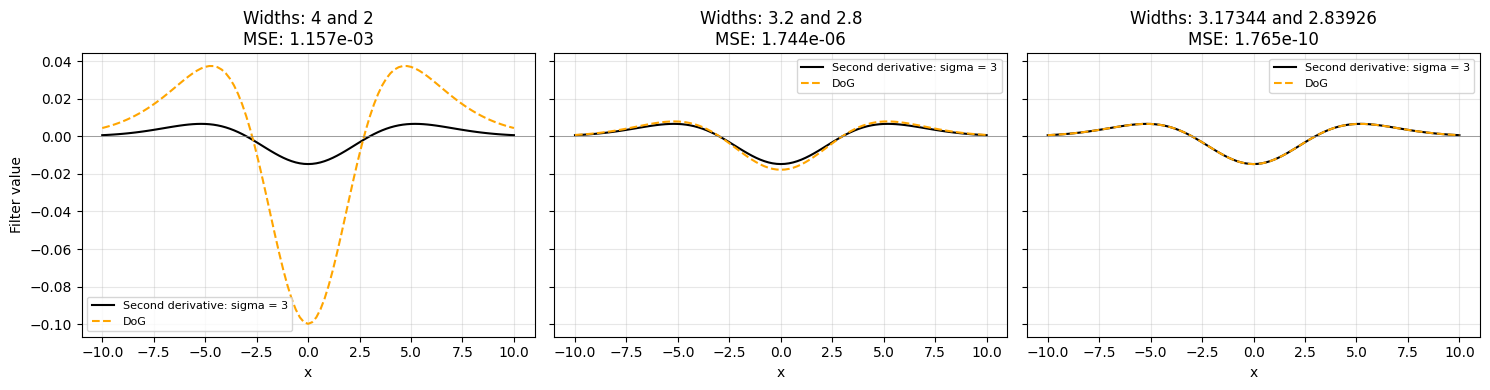

Best pair tested: (3.17344, 2.83926)
Mean squared error: 1.7647537597856368e-10


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# STEP 1: Gaussian functions
# INIT x = sample positions
x = np.linspace(-10, 10, 101)

def gaussian(x, sigma):
    return np.exp(-x**2 / (2 * sigma**2)) / (np.sqrt(2 * np.pi) * sigma)

def second_derivative_of_gaussian(x, sigma):
    return ((x**2 - sigma**2) / sigma**4) * gaussian(x, sigma)

# STEP 2: Compute second derivative with sigma = 3
target = second_derivative_of_gaussian(x, 3)

# STEP 3: Set pairs to compare
sigma_pairs = [
    (4.0, 2.0),
    (3.2, 2.8),
    (3.17344, 2.83926) # values from earlier numerical fit
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
errors = [] # save errors for each pair

# STEP 4: Compute DoG and compare with target for each pair
for ax, (sigma1, sigma2) in zip(axes, sigma_pairs):

    # wider Gaussian - narrower Gaussian
    dog = gaussian(x, sigma1) - gaussian(x, sigma2)

    mse = np.mean((dog - target)**2) # mean squared error
    errors.append(mse) # save calculation

    print("Gaussian widths:", sigma1, sigma2)
    print("Mean squared error:", mse)
    print()

    # Plot DoG and target
    ax.plot(x, target, color="black", label="Second derivative: sigma = 3")
    ax.plot(x, dog, "--", color="orange", label="DoG")

    ax.set_title(f"Widths: {sigma1:g} and {sigma2:g}\nMSE: {mse:.3e}")
    ax.set_xlabel("x")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# STEP 5: Save and display plots
axes[0].set_ylabel("Filter value")
plt.tight_layout()
plt.savefig("dog_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

# STEP 6: Find lowest error from tested pairs
best_index = int(np.argmin(errors))
best_pair = sigma_pairs[best_index]

print("Best pair tested:", best_pair)
print("Mean squared error:", errors[best_index])

The difference of Gaussians is almost identical to the second derivative of a Gaussian with sigma = 3.